# 06 — Hybrid Model (RF + SVM Ensemble)
Combine Random Forest and SVM using Stacking and Voting for improved accuracy.

**This is the novelty of the project.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None
import joblib, os
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = joblib.load('../../models/splits.pkl')
split_metadata = joblib.load('../../models/split_metadata.pkl')
train_groups = np.asarray(split_metadata['train_groups'])
le = joblib.load('../../models/label_encoder.pkl')
class_names = le.classes_
os.makedirs('../../outputs/plots', exist_ok=True)
print("Data loaded. Classes:", class_names)
print("Selected holdout fold:", split_metadata['selected_holdout_fold'])
print("Train plants:", split_metadata['train_plant_ids'])
print("Test plants:", split_metadata['test_plant_ids'])


Data loaded. Classes: ['Healthy' 'Moderate Stress' 'High Stress']
Selected holdout fold: 2
Train plants: [1, 2, 3, 5, 6, 8, 9, 10]
Test plants: [4, 7]


## Method 1 — Voting Classifier
Both RF and SVM vote — class with highest combined probability wins.

In [2]:
rf_params = dict(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)
svm_params = dict(
    kernel='rbf',
    C=0.8,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42,
)

rf = RandomForestClassifier(**rf_params)
svm = SVC(**svm_params)

voting = VotingClassifier(
    estimators=[('rf', rf), ('svm', svm)],
    voting='soft'   # uses probability scores
)
voting.fit(X_train, y_train)

y_pred_voting = voting.predict(X_test)

acc_voting = accuracy_score(y_test, y_pred_voting)

train_acc_voting = accuracy_score(y_train, voting.predict(X_train))

gap_voting = train_acc_voting - acc_voting

print(f"Voting Train Accuracy: {train_acc_voting * 100:.2f}%")
print(f"Voting Test Accuracy:  {acc_voting * 100:.2f}%")
print(f"Generalization Gap: {gap_voting * 100:.2f}%")

print("Status:", "Potential overfitting" if gap_voting > 0.03 else "No major overfitting signal")
print(classification_report(y_test, y_pred_voting, target_names=class_names))


Voting Train Accuracy: 99.17%
Voting Test Accuracy:  95.00%
Generalization Gap: 4.17%
Status: Potential overfitting
                 precision    recall  f1-score   support

        Healthy       0.89      0.95      0.92        58
Moderate Stress       0.96      0.89      0.92        81
    High Stress       0.98      1.00      0.99       101

       accuracy                           0.95       240
      macro avg       0.94      0.95      0.94       240
   weighted avg       0.95      0.95      0.95       240



## Method 2 — Stacking Classifier
RF and SVM predictions are fed into Logistic Regression as a meta-model.

In [3]:
rf2 = RandomForestClassifier(**rf_params)
svm2 = SVC(**svm_params)
stacking_cv = list(
    StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42).split(
        X_train, y_train, train_groups
    )
)

stacking = StackingClassifier(
    estimators=[('rf', rf2), ('svm', svm2)],
    final_estimator=LogisticRegression(max_iter=2000, C=0.5, class_weight='balanced'),
    cv=stacking_cv,
    passthrough=False
)
stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)

acc_stack = accuracy_score(y_test, y_pred_stack)

train_acc_stack = accuracy_score(y_train, stacking.predict(X_train))

gap_stack = train_acc_stack - acc_stack

print(f"Stacking Train Accuracy: {train_acc_stack * 100:.2f}%")
print(f"Stacking Test Accuracy:  {acc_stack * 100:.2f}%")
print(f"Generalization Gap: {gap_stack * 100:.2f}%")
print("Status:", "Potential overfitting" if gap_stack > 0.03 else "No major overfitting signal")
print(classification_report(y_test, y_pred_stack, target_names=class_names))


Stacking Train Accuracy: 100.00%
Stacking Test Accuracy:  99.58%
Generalization Gap: 0.42%
Status: No major overfitting signal
                 precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00        58
Moderate Stress       1.00      0.99      0.99        81
    High Stress       0.99      1.00      1.00       101

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



## Method 3 — Weighted Probability Averaging
Give RF 60% weight and SVM 40% weight based on their individual performance.

In [4]:
# Create the two base models.
# RF = Random Forest, SVM = Support Vector Machine.
rf3 = RandomForestClassifier(**rf_params)
svm3 = SVC(**svm_params)

# Train both models on the full training set.
# X_train contains all training samples.
# y_train contains the true label for each training sample.
rf3.fit(X_train, y_train)
svm3.fit(X_train, y_train)

# Get class probabilities for every sample in the test set.
# Shape is usually: (number_of_test_samples, number_of_classes)
rf_proba = rf3.predict_proba(X_test)
svm_proba = svm3.predict_proba(X_test)

# Example meaning of one row:
# rf_proba[0] = [0.1, 0.7, 0.2]
# healthy   #early_blight   #late_blight
# If class order is ['healthy', 'early_blight', 'late_blight'],
# then for test sample 1 the RF model says:
# healthy -> 0.1
# early_blight -> 0.7
# late_blight -> 0.2

# Weighted soft voting:
# give 60% importance to Random Forest
# give 40% importance to SVM
# This is done element-wise for every class probability.
combined = (0.6 * rf_proba) + (0.4 * svm_proba)

# Example for one sample:
# rf_proba[0]  = [0.1, 0.7, 0.2]
# svm_proba[0] = [0.2, 0.6, 0.2]
# combined[0]  = [0.14, 0.66, 0.20]

# Convert combined probabilities into final class prediction.
# np.argmax(..., axis=1) picks the index of the highest probability in each row.
# Example: [0.14, 0.66, 0.20] -> index 1
y_pred_weighted = np.argmax(combined, axis=1) #take column values

# Test accuracy of the weighted model.
acc_weighted = accuracy_score(y_test, y_pred_weighted)

# Do the same weighted prediction on training data
# so we can compare train accuracy vs test accuracy.
rf_train_proba = rf3.predict_proba(X_train)
svm_train_proba = svm3.predict_proba(X_train)

combined_train = (0.6 * rf_train_proba) + (0.4 * svm_train_proba)
y_pred_weighted_train = np.argmax(combined_train, axis=1)

# Training accuracy
train_acc_weighted = accuracy_score(y_train, y_pred_weighted_train)

# Difference between train and test accuracy.
# A large gap can indicate overfitting.
gap_weighted = train_acc_weighted - acc_weighted #testing

print(f"Weighted Train Accuracy: {train_acc_weighted * 100:.2f}%")
print(f"Weighted Test Accuracy:  {acc_weighted * 100:.2f}%")
print(f"Generalization Gap: {gap_weighted * 100:.2f}%")

print("Status:", "Potential overfitting" if gap_weighted > 0.03 else "No major overfitting signal")

# Detailed precision / recall / f1-score for each class
print(classification_report(y_test, y_pred_weighted, target_names=class_names))


Weighted Train Accuracy: 99.90%
Weighted Test Accuracy:  98.33%
Generalization Gap: 1.56%
Status: No major overfitting signal
                 precision    recall  f1-score   support

        Healthy       0.98      0.98      0.98        58
Moderate Stress       0.99      0.96      0.97        81
    High Stress       0.98      1.00      0.99       101

       accuracy                           0.98       240
      macro avg       0.98      0.98      0.98       240
   weighted avg       0.98      0.98      0.98       240



## Confusion Matrix — Best Hybrid Model

Best Hybrid Method: Stacking (99.58%)


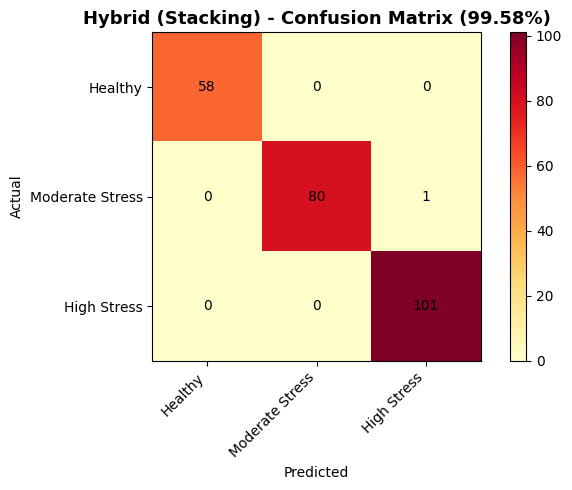

In [5]:
# Pick best hybrid
results = {
    'Voting':   (acc_voting,    y_pred_voting),
    'Stacking': (acc_stack,     y_pred_stack),
    'Weighted': (acc_weighted,  y_pred_weighted),
}


best_name = max(results, key=lambda k: results[k][0])
best_acc, best_pred = results[best_name]
print(f"Best Hybrid Method: {best_name} ({best_acc*100:.2f}%)")

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, best_pred)
if sns is not None:
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
    )
else:
    plt.imshow(cm, cmap='YlOrRd')
    for row, col in np.ndindex(cm.shape):
        plt.text(col, row, int(cm[row, col]), ha='center', va='center', color='black')
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.colorbar()

plt.title(f'Hybrid ({best_name}) - Confusion Matrix ({best_acc*100:.2f}%)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../../outputs/plots/confusion_matrix_hybrid.png', dpi=150)
plt.show()


## Cross-Validation — Best Hybrid

In [6]:
outer_group_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
cv_scores = []

for fold, (cv_train_idx, cv_val_idx) in enumerate(
    outer_group_cv.split(X_train, y_train, train_groups), start=1
):
    X_cv_train, X_cv_val = X_train[cv_train_idx], X_train[cv_val_idx]
    y_cv_train, y_cv_val = y_train.iloc[cv_train_idx], y_train.iloc[cv_val_idx]
    groups_cv_train = train_groups[cv_train_idx]

    if best_name == 'Stacking':
        inner_cv = list(
            StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42).split(
                X_cv_train, y_cv_train, groups_cv_train
            )
        )
        model = StackingClassifier(
            estimators=[
                ('rf', RandomForestClassifier(**rf_params)),
                ('svm', SVC(**svm_params)),
            ],
            final_estimator=LogisticRegression(max_iter=2000, C=0.5, class_weight='balanced'),
            cv=inner_cv,
            passthrough=False,
        )
        model.fit(X_cv_train, y_cv_train)
        fold_pred = model.predict(X_cv_val)
    elif best_name == 'Voting':
        model = VotingClassifier(
            estimators=[
                ('rf', RandomForestClassifier(**rf_params)),
                ('svm', SVC(**svm_params)),
            ],
            voting='soft'
        )
        model.fit(X_cv_train, y_cv_train)
        fold_pred = model.predict(X_cv_val)
    else:
        rf_cv = RandomForestClassifier(**rf_params)
        svm_cv = SVC(**svm_params)
        rf_cv.fit(X_cv_train, y_cv_train)
        svm_cv.fit(X_cv_train, y_cv_train)
        combined_cv = (0.6 * rf_cv.predict_proba(X_cv_val)) + (0.4 * svm_cv.predict_proba(X_cv_val))
        fold_pred = np.argmax(combined_cv, axis=1)

    fold_acc = accuracy_score(y_cv_val, fold_pred)
    cv_scores.append(fold_acc)
    print(f"Fold {fold}: {fold_acc * 100:.2f}%")

cv_scores = np.array(cv_scores)
print(f"Group CV Scores: {cv_scores.round(4)}")
print(f"Mean Group CV Accuracy: {cv_scores.mean()*100:.2f}% +/- {cv_scores.std()*100:.2f}%")


Fold 1: 99.17%


Fold 2: 100.00%


Fold 3: 99.58%


Fold 4: 100.00%
Group CV Scores: [0.9917 1.     0.9958 1.    ]
Mean Group CV Accuracy: 99.69% +/- 0.35%


In [7]:
# Save best hybrid model
joblib.dump(stacking, '../../models/hybrid_stacking_model.pkl')
joblib.dump(voting,   '../../models/hybrid_voting_model.pkl')
print("Saved: hybrid_stacking_model.pkl, hybrid_voting_model.pkl")

Saved: hybrid_stacking_model.pkl, hybrid_voting_model.pkl
